<a href="https://colab.research.google.com/github/gitbidec6/Machine-Learning-Works/blob/main/HSGPC_Modeling_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting High-Strength Glass Powder Concrete (HSGPC) Compressive Strength
**Based on the Paper:** *Machine learning prediction and explainability analysis of high strength glass powder concrete using SHAP PDP and ICE*

**Prepared:** 2025-07-13

This notebook implements KNN, RF, XGB and XGB optimized with PSO, FA, and GWO, with evaluation and explainability analysis (SHAP, PDP, ICE).

## Step 1: Load and Inspect Data

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_excel('/content/sample_data/Recycled.xlsx')
df.head()

,Cement,Flyash,Ground Granulated Blast-furnace Slag,Metakaolin,Water,Super Plasctcizer %,viscosity modifying agent admixture (%),Natural Coarse Aggregate (20mm),Natural Coarse Aggregate (10mm),Recycled Coarse Agrreagte (20mm),Recycled Coarse Agrreagte (10mm),Sand (kg/m3),Age of Testing (days),Compressive Strength N/mm2)
0,550,0,0,0,165,3.30,0.28,0,0,247,337,607,7,49.71
1,385,165,0,0,148,6.05,1.10,0,0,270,432,729,7,18.53
2,275,275,0,0,146,5.50,1.10,0,0,276,441,745,7,15.09
3,165,385,0,0,172,4.40,1.10,0,0,280,448,757,7,6.34
4,385,0,165,0,155,6.60,1.38,0,0,361,417,815,7,42.83


In [ ]:
# prompt: Frequency distribution of the dataset

# Display the frequency distribution of each column
for col in df.columns:
    print(f"Frequency distribution for column: {col}")
    print(df[col].value_counts())
    print("\n")

## Step 2: Outlier Detection using IQR Method

In [ ]:
# Interquartile Range filtering
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df_filtered = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
df_filtered.describe()

,Cement,Flyash,Ground Granulated Blast-furnace Slag,Metakaolin,Water,Super Plasctcizer %,viscosity modifying agent admixture (%),Natural Coarse Aggregate (20mm),Natural Coarse Aggregate (10mm),Recycled Coarse Agrreagte (20mm),Recycled Coarse Agrreagte (10mm),Sand (kg/m3),Age of Testing (days),Compressive Strength N/mm2)
count,66.000000,66.000000,66.000000,66.0,66.0,66.000000,66.0,66.0,66.0,66.000000,66.000000,66.000000,66.000000,66.000000
mean,302.954545,22.545455,37.772727,0.0,170.0,0.645591,0.0,0.0,0.0,481.590909,541.409091,653.545455,12.666667,23.610152
std,155.355318,44.002511,73.590090,0.0,0.0,0.590253,0.0,0.0,0.0,29.613914,33.453057,40.678924,11.048611,13.915824
min,113.000000,0.000000,0.000000,0.0,170.0,0.000000,0.0,0.0,0.0,415.000000,466.000000,562.000000,3.000000,6.000000
25%,189.000000,0.000000,0.000000,0.0,170.0,0.260500,0.0,0.0,0.0,458.000000,514.000000,620.000000,3.000000,13.625000
50%,262.000000,0.000000,0.000000,0.0,170.0,0.535000,0.0,0.0,0.0,490.500000,552.000000,666.000000,7.000000,19.195000
75%,378.000000,0.000000,0.000000,0.0,170.0,0.916500,0.0,0.0,0.0,505.000000,568.000000,688.000000,28.000000,31.765000
max,680.000000,146.000000,243.000000,0.0,170.0,2.040000,0.0,0.0,0.0,516.000000,579.000000,700.000000,28.000000,64.150000


Pearson Correlation Matrix:
                                                Cement        Flyash  \
Cement                                    1.000000e+00 -1.754424e-01   
Flyash                                   -1.754424e-01  1.000000e+00   
Ground Granulated Blast-furnace Slag     -4.159366e-01 -2.670368e-01   
Metakaolin                                         NaN           NaN   
Water                                              NaN           NaN   
Super Plasctcizer %                       8.795855e-01 -1.770735e-01   
 viscosity modifying agent admixture (%)           NaN           NaN   
Natural Coarse Aggregate (20mm)                    NaN           NaN   
Natural Coarse Aggregate (10mm)                    NaN           NaN   
Recycled Coarse Agrreagte (20mm)         -8.396193e-01 -6.736990e-02   
Recycled Coarse Agrreagte (10mm)         -8.329149e-01 -7.800620e-02   
Sand (kg/m3)                             -8.276295e-01 -8.484551e-02   
Age of Testing (days)               

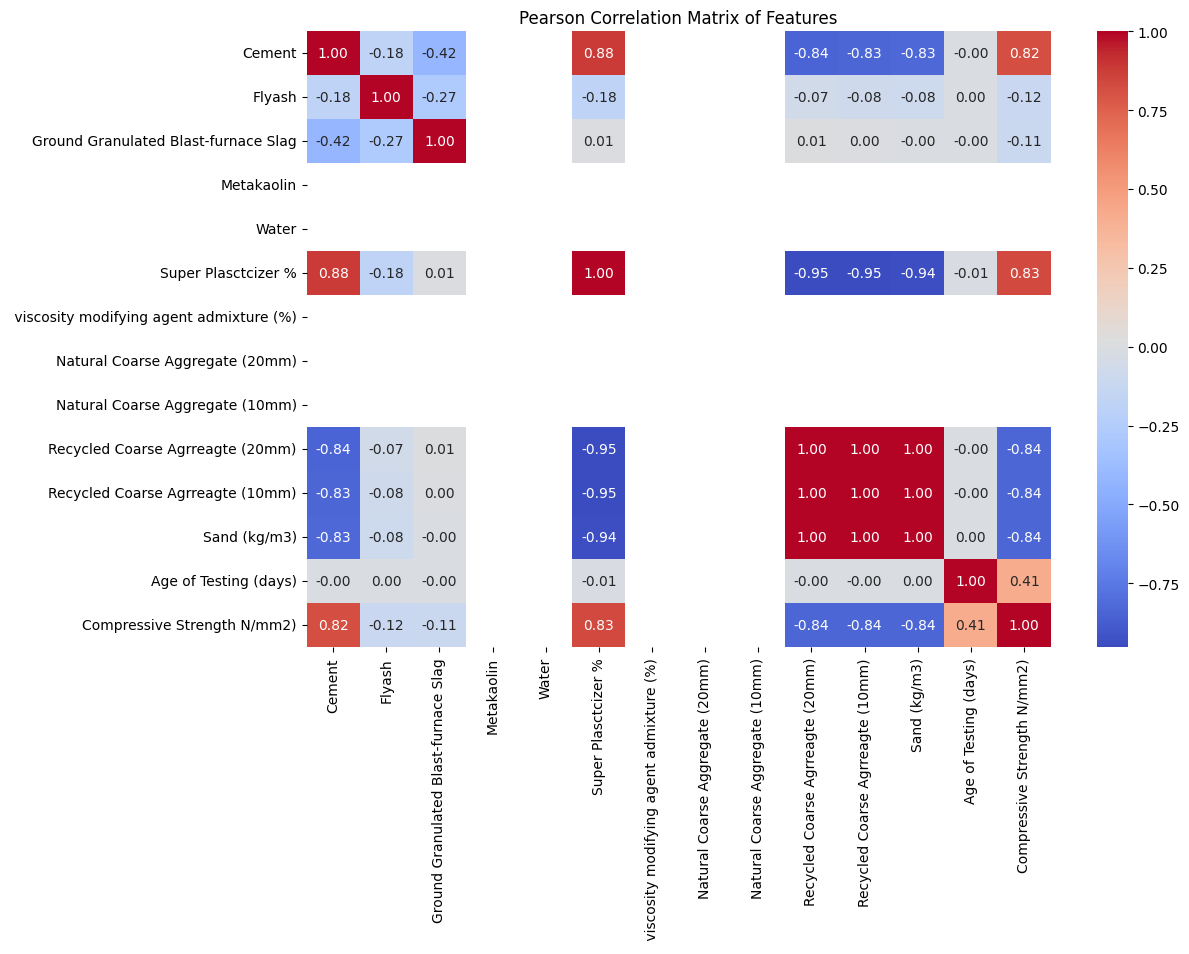

In [ ]:
# prompt: Pearson Correlation Analysis of the Dataset

# Step 3: Pearson Correlation Analysis
correlation_matrix = df_filtered.corr(method='pearson')
print("Pearson Correlation Matrix:")
print(correlation_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation Matrix of Features')
plt.show()

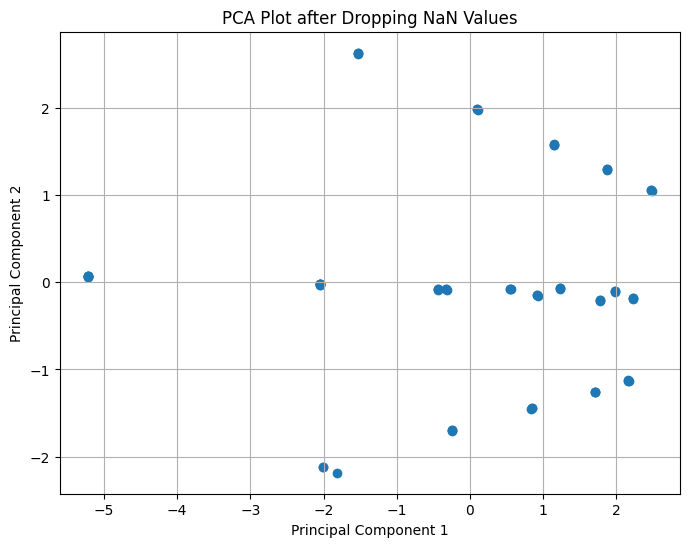

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Drop rows with any missing values
df_cleaned = df_filtered.dropna()

# Separate features and target (assuming 'Compressive Strength' is the target)
# Adjust the column name if it's different
X = df_cleaned.drop('Compressive Strength N/mm2)', axis=1)

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Plot the PCA components
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.title('PCA Plot after Dropping NaN Values')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

Pearson Correlation Matrix of Cleaned Dataset:
                                                Cement        Flyash  \
Cement                                    1.000000e+00 -1.754424e-01   
Flyash                                   -1.754424e-01  1.000000e+00   
Ground Granulated Blast-furnace Slag     -4.159366e-01 -2.670368e-01   
Metakaolin                                         NaN           NaN   
Water                                              NaN           NaN   
Super Plasctcizer %                       8.795855e-01 -1.770735e-01   
 viscosity modifying agent admixture (%)           NaN           NaN   
Natural Coarse Aggregate (20mm)                    NaN           NaN   
Natural Coarse Aggregate (10mm)                    NaN           NaN   
Recycled Coarse Agrreagte (20mm)         -8.396193e-01 -6.736990e-02   
Recycled Coarse Agrreagte (10mm)         -8.329149e-01 -7.800620e-02   
Sand (kg/m3)                             -8.276295e-01 -8.484551e-02   
Age of Testing (d

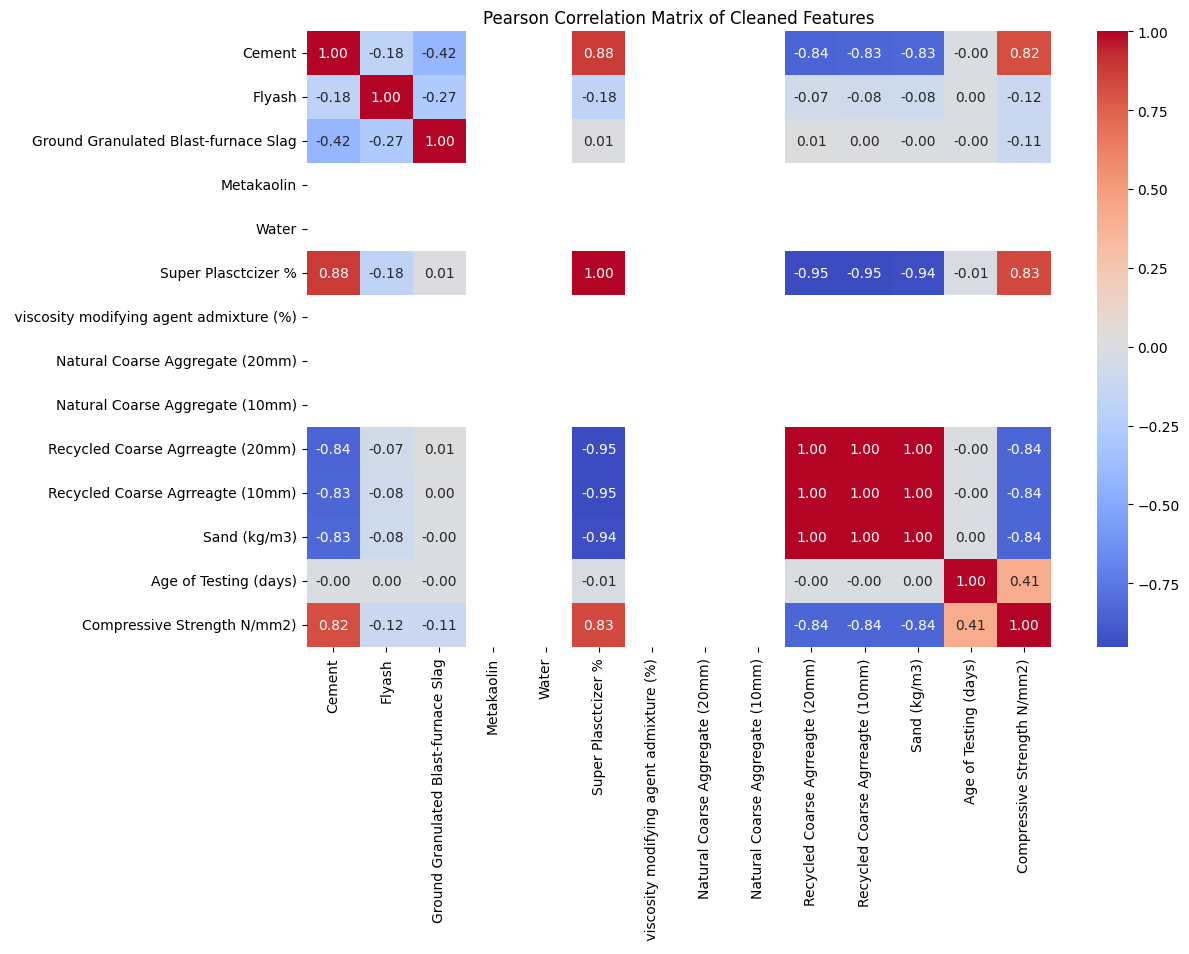

In [ ]:
# prompt: Plot the Pearson Correlation Analysis of the cleaned dataset

import matplotlib.pyplot as plt
# Assuming 'df_cleaned' is the DataFrame after dropping NaN values

# Step 3: Pearson Correlation Analysis on the cleaned dataset
correlation_matrix_cleaned = df_cleaned.corr(method='pearson')
print("Pearson Correlation Matrix of Cleaned Dataset:")
print(correlation_matrix_cleaned)

# Plot the Pearson Correlation Matrix of the cleaned dataset
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix_cleaned, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation Matrix of Cleaned Features')
plt.show()

In [ ]:
Pearson Correlation Analysis of the Dataset

SyntaxError: invalid syntax (ipython-input-4-3508963197.py, line 1)

## Step 3: Standardization and Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_filtered.drop(columns=['Compressive Strength N/mm2)'])
y = df_filtered['Compressive Strength N/mm2)']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

## Step 4: Train KNN, RF, and XGB Models

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

knn = KNeighborsRegressor(n_neighbors=5).fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, objective='reg:squarederror').fit(X_train, y_train)

## Step 5: Model Evaluation

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def evaluate_model(name, model):
    y_pred = model.predict(X_test)
    return {
        'Model': name,
        'R2': r2_score(y_test, y_pred),
        'RMSE': mean_squared_error(y_test, y_pred, squared=False),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
        'MAPE': np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    }

results = pd.DataFrame([
    evaluate_model("KNN", knn),
    evaluate_model("RF", rf),
    evaluate_model("XGB", xgb)
])
results

## Step 6: Optimization with PSO, FA, and GWO
*To be implemented in next section*

## Step 7: Explainability (SHAP, PDP, ICE)
*To be implemented in next section*